# Del 0: Innledning
# Romlig analyse av tilfluktsrom og befolkning i Agder

## 0.1 Bakgrunn

Som en del av temaet *Totalforsvarets år* undersøker denne notebooken hvordan tilfluktsrom er geografisk distribuert i forhold til befolkningen i Agder.

Tilgang til tilfluktsrom er en sentral del av sivil beredskap. Den romlige fordelingen av slike anlegg kan ha stor betydning for hvor godt befolkningen er beskyttet i en krisesituasjon.

Ved å kombinere data om tilfluktsrom med befolkningsdata og geografiske analyser, er det mulig å identifisere områder med god eller svak dekning. Dette gir et mer nyansert bilde av beredskapssituasjonen enn å kun visualisere hvor tilfluktsrommene ligger.

---

## 0.2 Problemstilling

Analysen forsøker å besvare følgende spørsmål:

1. Hvor ligger tilfluktsrommene i Agder?
2. Hvordan er de geografisk fordelt i forhold til hvor befolkningen bor?
3. Finnes det områder med høy befolkningstetthet som har svak tilgang til tilfluktsrom?
4. Hvordan kan romlige analysemetoder brukes for å avdekke slike mønstre?

---

## 0.3 Planlagt analyse

Notebooken dokumenterer en fullstendig romlig analyseprosess som inkluderer:

- innlasting av flere geografiske datasett
- filtrering av data til Agder
- visualisering av tilfluktsrom og befolkningsdata
- bufferanalyse rundt tilfluktsrom
- overlay-analyse for å identifisere dekkede og ikke-dekkede områder
- romlig aggregering av befolkning innenfor og utenfor dekning
- rasteranalyse av terreng (helning og egnethet)

Målet er å gå fra en enkel visualisering av data til en mer analytisk vurdering av geografisk dekning og beredskap.

---

## 0.4 Datasett

Analysen tar utgangspunkt i følgende datasett:

- **Tilfluktsrom**: punktdata fra prosjektets PostGIS-database (`public.shelters`)
- **Fylkesgrenser**: polygondata fra prosjektets PostGIS-database (`public.fylker`)
- **Befolkningsrutenett 250 m**: data fra GeoNorge/SSB, importert til PostGIS (`public.befolkning_rutenett_250m_2025`)
- **Terrengdata (DEM)**: rasterdata brukt til helningsanalyse, polygonisering og hillshade

Datasettet for tilfluktsrom dekker hele Norge og filtreres til Agder ved hjelp av romlige operasjoner.
Befolkningsdata brukes for å analysere hvor mennesker faktisk bor, og gjør det mulig å vurdere dekning i et samfunnsperspektiv.

---

## 0.5 Verktøy

Følgende Python-biblioteker benyttes i analysen:

- `pandas`
- `geopandas`
- `matplotlib`
- `rasterio`
- `shapely`
- `sqlalchemy`
- `duckdb`

Disse verktøyene brukes til å håndtere data, utføre romlige analyser og visualisere resultatene i notebooken.

# Del 1. Oppsett og biblioteker

I denne delen settes det tekniske grunnlaget for analysen.

Nødvendige Python-biblioteker importeres, og det gjøres enkle innstillinger for å sikre at data og visualiseringer presenteres på en ryddig og lesbar måte i notebooken.

## 1.1 Import av biblioteker

Her importeres bibliotekene som brukes i analysen.

Disse dekker:
- håndtering av tabulære data
- romlige analyser
- visualisering
- rasteranalyse
- databasetilkobling

Ved å samle alle imports på ett sted blir notebooken mer oversiktlig og enklere å vedlikeholde.

In [1]:
import os
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

import sqlalchemy
from sqlalchemy import text

import rasterio
from rasterio.plot import show
from rasterio.features import shapes

from shapely.geometry import shape

from dotenv import load_dotenv

import duckdb

## 1.2 Valg av arbeidsmiljø og visualiseringsinnstillinger

For å gjøre utskrifter og figurer lettere å lese, settes noen enkle visningsinnstillinger.
Dette påvirker ikke selve analysen, men gjør det enklere å tolke resultater og jobbe effektivt i notebooken.

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

# Del 2. Innlasting og kontroll av data

I denne delen lastes de sentrale datasettene som brukes i analysen inn i notebooken.

Målet er å etablere et tydelig og kontrollert datagrunnlag før videre romlige analyser gjennomføres.
Siden flere av datasettene er lagret i prosjektets PostgreSQL/PostGIS-database, brukes databasen som primær datakilde.

Følgende datasett leses inn:

- fylkesgrenser fra `public.fylker`
- tilfluktsrom fra `public.shelters`
- befolkningsrutenett fra `public.befolkning_rutenett_250m_2025`

Alle datasettene kontrolleres etter innlasting for å sikre at struktur, geometri og koordinatsystem er korrekt før videre analyse.

## 2.1 Laste miljøvariabler og opprette databaseforbindelse

I denne delen lastes miljøvariabler fra prosjektets `.env`-fil, og det opprettes en forbindelse til PostgreSQL/PostGIS-databasen.
Dette gjør det mulig å hente geografiske data direkte fra databasen og sikre en konsistent arbeidsflyt i analysen.
For å bekrefte at tilkoblingen fungerer, kjøres en enkel testspørring mot databasen.

In [3]:
load_dotenv(Path("..") / ".env")

database_url = os.getenv("DATABASE_URL")

print("DATABASE_URL funnet:", database_url is not None)

DATABASE_URL funnet: True


## 2.2 Kontrollere at databaseforbindelsen fungerer

Etter at miljøvariablene er lastet inn, opprettes en forbindelse til databasen. Deretter kjøres en enkel testspørring for å kontrollere at forbindelsen fungerer som forventet. Dette er viktig før videre innlasting av geografiske data fra databasen.

In [4]:
engine = sqlalchemy.create_engine(database_url)

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database(), current_user;"))
    for row in result:
        print("Tilkobling vellykket")
        print("Database:", row[0])
        print("Bruker:", row[1])

Tilkobling vellykket
Database: postgres
Bruker: postgres


## 2.3 Lese inn fylkesgrense for Agder

For å avgrense analysen til riktig studieområde leses fylkesgrensen for Agder inn fra tabellen `public.fylker`.

Denne geometrien brukes videre som geografisk avgrensning for resten av analysen. Ved å hente fylkespolygonet direkte fra databasen sikres det at analyseområdet er konsistent med de øvrige dataene i prosjektet.

In [5]:
sql_agder = """
SELECT
    id,
    navn,
    geomfylke
FROM public.fylker
WHERE navn = 'Agder'
"""

gdf_agder = gpd.read_postgis(sql_agder, engine, geom_col="geomfylke")

gdf_agder.head()

,id,navn,geomfylke
0,5,Agder,"POLYGON ((7.21467 59.67269, 7.21112 59.66901, ..."


## 2.4 Lese inn tilfluktsrom i Agder

Etter at analyseområdet er definert, leses tilfluktsrom inn fra tabellen `public.shelters`.

Datasettet filtreres romlig direkte i SQL ved hjelp av `ST_Within`, slik at bare tilfluktsrom som ligger innenfor Agder tas med videre. Dette gjør innlastingen mer effektiv og sikrer at analysen fra starten av er avgrenset til riktig område.

In [6]:
sql_shelters_agder = """
SELECT
    fid,
    romnr,
    plasser,
    adresse,
    navnerom,
    posisjon
FROM public.shelters
WHERE ST_Within(
    posisjon,
    (SELECT geomfylke FROM public.fylker WHERE navn = 'Agder')
)
"""

gdf_shelters = gpd.read_postgis(sql_shelters_agder, engine, geom_col="posisjon")

gdf_shelters.head()

,fid,romnr,plasser,adresse,navnerom,posisjon
0,47,1688,136,BANEHEIVEIEN,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (7.98237 58.14915)
1,48,1707,195,BYDALSVEIEN 19,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (7.92203 58.14805)
2,49,1740,65,FREDRIK FRANSSONSVEI 4,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (8.08398 58.183)
3,50,1755,235,GROSTØLVEIEN 4 E,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (8.03204 58.20018)
4,51,1756,500,GRÅGÅSVEIEN 43,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (7.93656 58.12147)


## 2.5 Lese inn befolkningsrutenett fra PostGIS

For å analysere forholdet mellom tilfluktsrom og hvor mange mennesker det faktisk bor, leses befolkningsrutenettet inn fra tabellen `public.befolkning_rutenett_250m_2025`.

Datasettet er opprinnelig hentet fra GeoNorge/SSB og senere importert til prosjektets PostgreSQL/PostGIS-database. Hver rad representerer én rute på 250 x 250 meter, og kolonnen `poptot` angir totalt antall personer i ruten.

Dette datasettet gir et detaljert og egnet grunnlag for å analysere geografisk dekning av tilfluktsrom i forhold til befolkning.

In [7]:
sql_population = """
SELECT *
FROM public.befolkning_rutenett_250m_2025
"""

gdf_population = gpd.read_postgis(
    sql_population,
    engine,
    geom_col="geometry"
)

gdf_population.head()

,ogc_fid,objtype,lokalid,navnerom,versjonid,oppdateringsdato,datauttaksdato,opphav,ssbid250m,poptot,statistikkar,geometry
0,57777,BefolkningPåRuter250m,cb57edc7-3484-4500-afb6-670d2b548335,http://data.geonorge.no/sosi/befolkning/befolk...,20250101,2025-01-01 00:00:00+00:00,2025-10-06 10:21:01+00:00,SSB,19840006800750,2,2025,"MULTIPOLYGON (((-15749.984 6800749.936, -15999..."
1,57778,BefolkningPåRuter250m,648e70b2-b1c1-4c09-9da5-f493bf5a6b79,http://data.geonorge.no/sosi/befolkning/befolk...,20250101,2025-01-01 00:00:00+00:00,2025-10-06 10:21:01+00:00,SSB,19840006801000,5,2025,"MULTIPOLYGON (((-15749.984 6800999.936, -15999..."
2,57779,BefolkningPåRuter250m,f2fff560-ac25-4e37-8d1a-6ff73cf3fb9e,http://data.geonorge.no/sosi/befolkning/befolk...,20250101,2025-01-01 00:00:00+00:00,2025-10-06 10:21:01+00:00,SSB,19842506803250,1,2025,"MULTIPOLYGON (((-15499.984 6803249.936, -15749..."
3,57780,BefolkningPåRuter250m,6a1783cb-543d-4f1a-b919-f3b6df566cd7,http://data.geonorge.no/sosi/befolkning/befolk...,20250101,2025-01-01 00:00:00+00:00,2025-10-06 10:21:01+00:00,SSB,19850006809000,2,2025,"MULTIPOLYGON (((-14749.984 6808999.936, -14999..."
4,57781,BefolkningPåRuter250m,09aa4aed-3ce5-43e9-b07d-b33ef10172df,http://data.geonorge.no/sosi/befolkning/befolk...,20250101,2025-01-01 00:00:00+00:00,2025-10-06 10:21:01+00:00,SSB,19860006817750,1,2025,"MULTIPOLYGON (((-13749.984 6817749.936, -13999..."


## 2.6 Kontroll av struktur og innhold

Etter innlasting kontrolleres datasettene for å sikre at de er korrekt lest inn og klare for videre analyse.

Det undersøkes blant annet:
- antall objekter
- kolonner og datastruktur
- koordinatsystem
- sentrale variabler i befolkningsdatasettet

Denne typen kontroll er viktig fordi feil i datagrunnlaget kan gi misvisende resultater senere i analysen.

In [8]:
print("Agder")
print("Antall objekter:", len(gdf_agder))
print("CRS:", gdf_agder.crs)

print("\nTilfluktsrom")
print("Antall objekter:", len(gdf_shelters))
print("CRS:", gdf_shelters.crs)

print("\nBefolkningsrutenett")
print("Antall objekter:", len(gdf_population))
print("CRS:", gdf_population.crs)

Agder
Antall objekter: 1
CRS: EPSG:4326

Tilfluktsrom
Antall objekter: 65
CRS: EPSG:4326

Befolkningsrutenett
Antall objekter: 224761
CRS: EPSG:25833


Det observeres at datasettene har ulike koordinatsystemer.
Fylkesgrensen og tilfluktsrommene er i EPSG:4326 (geografiske koordinater),
mens befolkningsrutenettet er i EPSG:25833 (projisert koordinatsystem i meter).

Dette vil bli håndtert i Del 3, der datasettene reprojiseres til et felles koordinatsystem før videre analyse.

Videre undersøkes kolonnene i datasettene for å få oversikt over hvilke attributter som er tilgjengelige. For befolkningsdatasettet er det spesielt viktig å bekrefte at kolonnen `poptot` finnes, siden denne brukes videre i analysen av befolkningsdekning.

In [9]:
print("Kolonner i Agder:")
print(gdf_agder.columns.tolist())

print("\nKolonner i shelters:")
print(gdf_shelters.columns.tolist())

print("\nKolonner i befolkningsrutenett:")
print(gdf_population.columns.tolist())

Kolonner i Agder:
['id', 'navn', 'geomfylke']

Kolonner i shelters:
['fid', 'romnr', 'plasser', 'adresse', 'navnerom', 'posisjon']

Kolonner i befolkningsrutenett:
['ogc_fid', 'objtype', 'lokalid', 'navnerom', 'versjonid', 'oppdateringsdato', 'datauttaksdato', 'opphav', 'ssbid250m', 'poptot', 'statistikkar', 'geometry']


For befolkningsdatasettet undersøkes også noen sentrale variabler nærmere. Dette gir bedre innsikt i hvordan datasettet er bygd opp, og bekrefter at `poptot` kan brukes som mål på befolkning per rute.

In [10]:
gdf_population[["ssbid250m", "poptot", "statistikkar"]].head()

,ssbid250m,poptot,statistikkar
0,19840006800750,2,2025
1,19840006801000,5,2025
2,19842506803250,1,2025
3,19850006809000,2,2025
4,19860006817750,1,2025


Til slutt vises en enkel statistisk oppsummering av befolkningsvariabelen `poptot`. Dette gir en første indikasjon på hvordan befolkningen er fordelt mellom rutene.

In [11]:
gdf_population["poptot"].describe()

count    224761.000000
mean         24.852479
std          69.261399
min           1.000000
25%           2.000000
50%           5.000000
75%          13.000000
max        2274.000000
Name: poptot, dtype: float64

## 2.7 Første visualisering av studieområdet

Som en første romlig kontroll visualiseres fylkesgrensen for Agder sammen med tilfluktsrommene som er hentet inn fra databasen.

Kartet fungerer som en kvalitetssjekk og gir samtidig en første oversikt over hvordan tilfluktsrommene er geografisk fordelt i studieområdet.

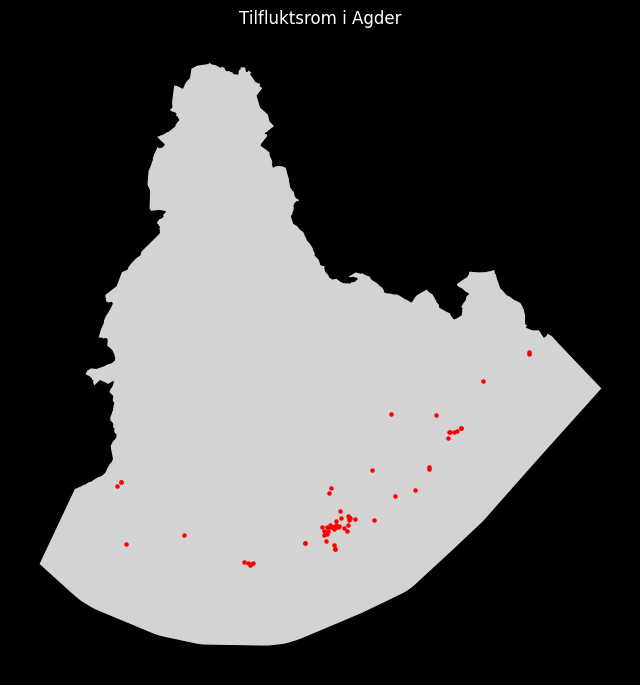

In [12]:
fig, ax = plt.subplots(figsize=(8, 10))

gdf_agder.plot(ax=ax, color="lightgrey", edgecolor="black")
gdf_shelters.plot(ax=ax, color="red", markersize=5)

ax.set_title("Tilfluktsrom i Agder")
ax.set_axis_off()

plt.show()

Visualiseringen viser at tilfluktsrommene er fordelt ulikt i Agder, og danner et første grunnlag for å undersøke om denne fordelingen samsvarer med hvor befolkningen bor.

# Del 3. Dataklargjøring

I denne delen klargjøres datasettene for videre romlig analyse.

Etter innlasting i Del 2 ble det observert at datasettene ikke har samme koordinatsystem. Før romlige operasjoner som buffer, overlay og klipping kan gjennomføres, må dataene derfor harmoniseres og kontrolleres nærmere.

I denne delen undersøkes koordinatsystemene mer systematisk, datasettene reprojiseres til et felles CRS, og geometriene kontrolleres for å sikre at dataene er klare for analyse.
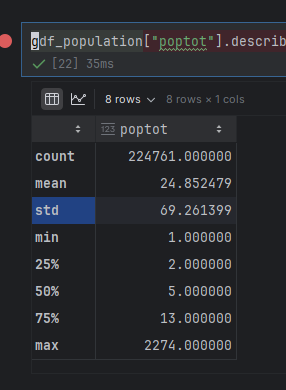
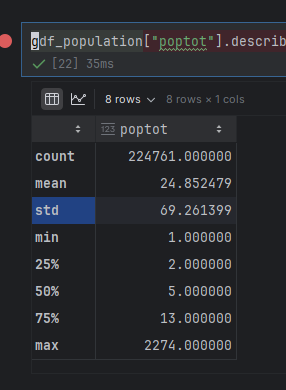

## 3.1 Kontroll av koordinatsystemer

Før videre analyse er det nødvendig å kontrollere koordinatsystemene i datasettene på nytt.

Koordinatsystemet, eller CRS, bestemmer hvordan geografiske objekter er plassert i rommet. Dersom to datasett bruker ulike koordinatsystemer, vil de ikke nødvendigvis ligge riktig i forhold til hverandre i analyser og kart.

Dette er spesielt viktig i denne oppgaven fordi buffer- og overlay-analyser krever at datasettene har samme romlige referansesystem.

In [13]:
print("CRS for Agder:", gdf_agder.crs)
print("CRS for tilfluktsrom:", gdf_shelters.crs)
print("CRS for befolkningsrutenett:", gdf_population.crs)

CRS for Agder: EPSG:4326
CRS for tilfluktsrom: EPSG:4326
CRS for befolkningsrutenett: EPSG:25833


## 3.2 Reprojisering til felles koordinatsystem

Siden datasettene bruker ulike koordinatsystemer, må de reprojiseres til et felles CRS før videre analyse.

I denne analysen brukes `EPSG:25833`, som er et projisert koordinatsystem der avstander og arealer måles i meter. Dette er godt egnet for analyser som buffer, overlay og romlig aggregering.

Agder og tilfluktsrom reprojiseres derfor fra `EPSG:4326` til `EPSG:25833`, slik at alle datasettene kan brukes sammen i videre analyser.

In [14]:
gdf_agder = gdf_agder.to_crs("EPSG:25833")
gdf_shelters = gdf_shelters.to_crs("EPSG:25833")

Etter reprojisering kontrolleres koordinatsystemene på nytt for å bekrefte at alle datasettene nå bruker samme CRS.

In [15]:
print("CRS for Agder etter reprojisering:", gdf_agder.crs)
print("CRS for tilfluktsrom etter reprojisering:", gdf_shelters.crs)
print("CRS for befolkningsrutenett:", gdf_population.crs)

CRS for Agder etter reprojisering: EPSG:25833
CRS for tilfluktsrom etter reprojisering: EPSG:25833
CRS for befolkningsrutenett: EPSG:25833


## 3.3 Kontroll av geometri

Etter at koordinatsystemene er harmonisert, kontrolleres geometriene i datasettene.

Gyldig geometri er en forutsetning for at romlige operasjoner skal fungere korrekt. Dersom geometriene er ugyldige, kan dette føre til feil i analyser som buffer, overlay og klipping.

Det undersøkes derfor om geometriene i datasettene er gyldige før analysen går videre.

In [16]:
print("Gyldige geometrier i Agder:", gdf_agder.is_valid.sum(), "av", len(gdf_agder))
print("Gyldige geometrier i tilfluktsrom:", gdf_shelters.is_valid.sum(), "av", len(gdf_shelters))
print("Gyldige geometrier i befolkningsrutenett:", gdf_population.is_valid.sum(), "av", len(gdf_population))

Gyldige geometrier i Agder: 1 av 1
Gyldige geometrier i tilfluktsrom: 65 av 65
Gyldige geometrier i befolkningsrutenett: 224761 av 224761


Kontrollen viser om datasettene har gyldige geometrier og dermed kan brukes videre i romlige operasjoner. Dersom alle geometrier er gyldige, styrker dette påliteligheten i den videre analysen.

## 3.4 Klargjøring av analyseklare datasett

Etter kontroll av koordinatsystemer og geometri er datasettene nå klargjort for videre analyse.

Alle datasettene bruker nå samme koordinatsystem (`EPSG:25833`), og geometriene er kontrollert. Dette betyr at de videre kan brukes sammen i romlige operasjoner som buffersoner, overlay-analyse og romlig aggregering.

I neste del brukes disse klargjorte datasettene til å undersøke den geografiske dekningen av tilfluktsrom i forhold til befolkningen i Agder.

# Del 4. Vektoranalyse

I denne delen gjennomføres den sentrale romlige analysen i oppgaven.

Basert på de klargjorte datasettene fra Del 3 undersøkes den geografiske dekningen av tilfluktsrom i forhold til befolkningen i Agder.

Analysen består av flere steg:

- det opprettes buffersoner rundt tilfluktsrom for å representere tilgjengelighet
- bufferområdene slås sammen for å unngå overlapp
- befolkningsrutenettet sammenlignes med bufferområdene ved hjelp av overlay-analyse
- det beregnes hvor mange mennesker som bor innenfor og utenfor dekning
- det gjennomføres en romlig aggregering for å oppsummere resultatene
- resultatene visualiseres og tolkes

Formålet er å identifisere områder med god og svak dekning, og dermed gi en mer presis vurdering av beredskapssituasjonen i regionen.

## 4.1 Buffer rundt tilfluktsrom

For å analysere tilgjengeligheten til tilfluktsrom opprettes det buffersoner rundt hvert tilfluktsrom.

En buffer representerer et område innenfor en gitt avstand fra et objekt. I denne analysen brukes en buffer på 500 meter rundt hvert tilfluktsrom. Dette kan tolkes som en forenklet modell for hvor langt en person kan bevege seg for å nå et tilfluktsrom.

Ved å lage buffersoner kan vi senere undersøke hvilke deler av befolkningen som bor innenfor eller utenfor disse områdene.

In [17]:
buffer_distance = 500  # meter

gdf_shelters["buffer"] = gdf_shelters.geometry.buffer(buffer_distance)

For å kontrollere at buffersonene er riktig opprettet, visualiseres de sammen med tilfluktsrommene og fylkesgrensen.

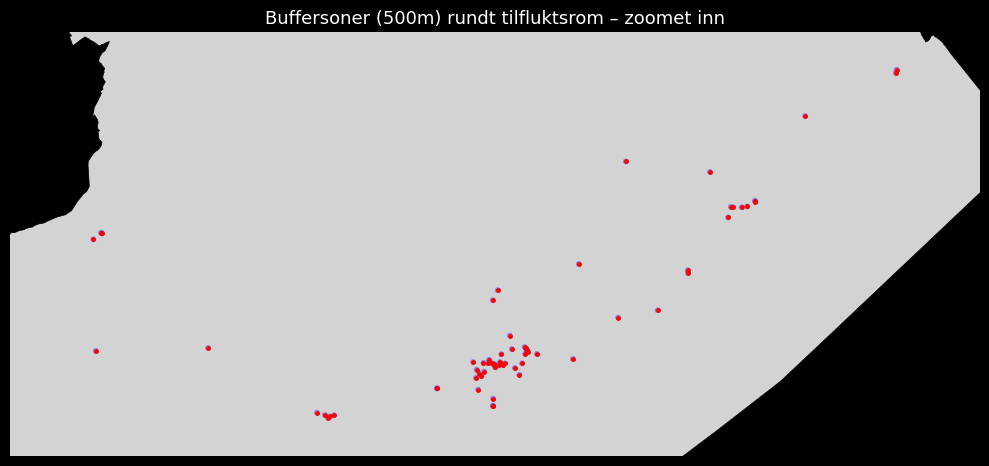

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))

# Hent bounding box fra bufferne – zoom dit det skjer noe
minx, miny, maxx, maxy = gdf_shelters.set_geometry("buffer").total_bounds

# Legg til litt luft rundt (10% av bredde/høyde)
padding_x = (maxx - minx) * 0.1
padding_y = (maxy - miny) * 0.1

# Tegn bakgrunnskart
gdf_agder.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)

# Tegn buffersoner
gdf_shelters.set_geometry("buffer").plot(
    ax=ax,
    color="blue",
    alpha=0.3,
    edgecolor="blue",
    linewidth=0.4
)

# Tegn tilfluktsrom som punkter
gdf_shelters.plot(ax=ax, color="red", markersize=6, zorder=5)

# Zoom inn på bufferne
ax.set_xlim(minx - padding_x, maxx + padding_x)
ax.set_ylim(miny - padding_y, maxy + padding_y)

ax.set_title("Buffersoner (500m) rundt tilfluktsrom – zoomet inn", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Buffersonene er i dette tilfellet relativt små sammenlignet med hele fylkets utstrekning, og blir derfor lite synlige i oversiktskartet. Kartet fungerer derfor primært som en visuell kontroll av at buffersonene er korrekt generert.

Den videre analysen baseres på de underliggende geometriene, ikke kun på visuell inspeksjon.

## 4.2 Sammenslåing av overlappende buffere

Buffersonene rundt tilfluktsrommene overlapper i mange områder, spesielt der tilfluktsrommene ligger tett.

For å unngå at de samme områdene telles flere ganger, slås buffersonene sammen til én samlet flate. Denne representerer det totale området som er dekket av minst ett tilfluktsrom.

Dette er et viktig steg før videre analyse, fordi det gir et korrekt grunnlag for å beregne hvor stor del av befolkningen som er dekket.

In [19]:
# Lag en GeoDataFrame med buffersonene som aktiv geometri
gdf_buffers = gdf_shelters.set_geometry("buffer").copy()

# Slå sammen alle buffere til én samlet geometri
combined_buffer = gdf_buffers.geometry.union_all()

## 4.3 Overlay mot befolkningsrutenett

For å analysere hvilke deler av befolkningen som er dekket av tilfluktsrom, sammenlignes det samlede bufferområdet med befolkningsrutenettet.

Dette gjøres ved hjelp av en overlay-operasjon, der befolkningsruter som ligger innenfor buffersonene identifiseres.

Resultatet av denne operasjonen er et nytt datasett som representerer de områdene der befolkningen har tilgang til tilfluktsrom innenfor den definerte avstanden.

In [20]:
# Gjør combined_buffer om til GeoDataFrame
gdf_combined_buffer = gpd.GeoDataFrame(
    geometry=[combined_buffer],
    crs=gdf_shelters.crs
)

# Finn befolkningsruter som ligger innenfor buffer
gdf_population_covered = gpd.overlay(
    gdf_population,
    gdf_combined_buffer,
    how="intersection"
)

### Kontroll av resultatet

Vi sjekker hvor mange befolkningsruter som havnet innenfor buffersonene.
Dette er en viktig kontroll – hvis tallet er 0 eller veldig lavt,
tyder det på et CRS-problem eller feil i overlay-operasjonen.

In [21]:
print("Antall befolkningsruter innenfor buffer:", len(gdf_population_covered))

Antall befolkningsruter innenfor buffer: 828


### Visualisering av dekkede områder

Vi visualiserer resultatet ved å zoome inn på Kristiansand-området,
der tilfluktsrommene er mest konsentrert.

Kartet viser tre lag:
- **Grå ruter** – befolkningsruter uten dekning
- **Grønne ruter** – befolkningsruter innenfor 500m fra et tilfluktsrom
- **Røde punkter** – tilfluktsrommene

Legg merke til at de grønne rutene er små øyer i et stort grått hav.
Dette antyder at store deler av befolkningen i Agder ikke har et
tilfluktsrom i nærheten – noe vi vil bekrefte med tall i neste steg.

Merk: kartet lagres som bildefil for å sikre hvit bakgrunn uavhengig
av Jupyter-temaet som er aktivt.

In [22]:
# Sjekk hvor shelters og dekkede ruter faktisk ligger
print("Shelters bounds:")
print(gdf_shelters.total_bounds)

print("\nDekkede ruter bounds:")
print(gdf_population_covered.total_bounds)

print("\nBefolkning bounds (sample):")
print(gdf_population.total_bounds)

Shelters bounds:
[  10762.00694617 6456301.99799455  165316.00022397 6523335.99962464]

Dekkede ruter bounds:
[  10703.98823051 6455801.99799455  165816.00022397 6523800.56630753]

Befolkning bounds (sample):
[ -74999.9735 6450999.9911 1098498.318  7937999.2751]


### Kontroll av geografisk utstrekning (bounds)

For å sikre at alle datasett ligger i samme geografiske område, kontrolleres deres bounding boxes (utstrekning i koordinater).

`total_bounds` gir minimum og maksimum koordinater for hvert datasett i formatet:
[minx, miny, maxx, maxy]

Ved å sammenligne disse verdiene kan vi kontrollere at:

- tilfluktsrommene ligger innenfor Agder
- de dekkede befolkningsrutene overlapper med både rutenettet og buffersonene
- datasett faktisk ligger i samme koordinatsystem og område

Dette er en viktig feilsjekk for å avdekke problemer med feil projeksjon (CRS) eller feil i overlay-analysen.

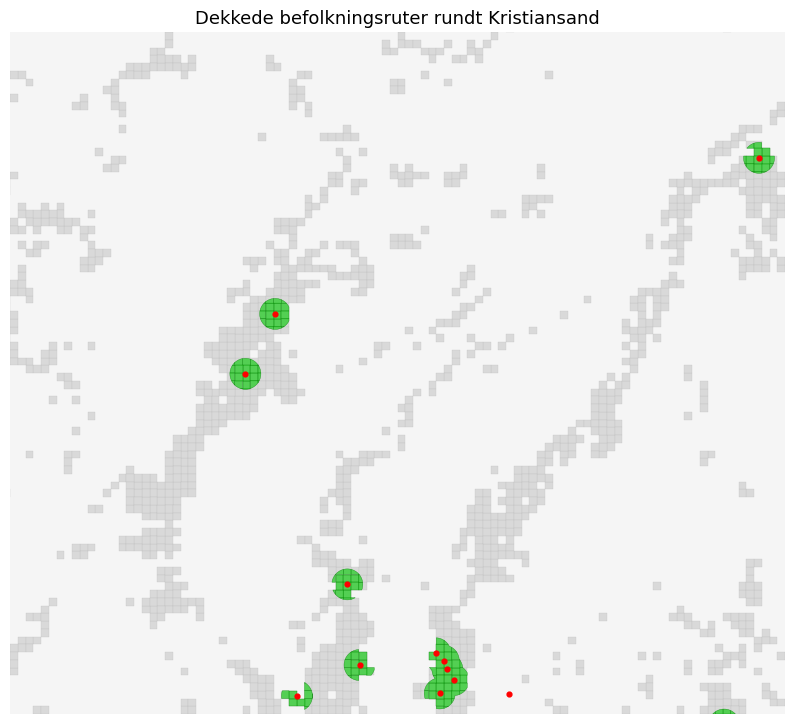

In [24]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# Reset matplotlib (viktig)
plt.close("all")
mpl.rcdefaults()

# Tving hvit bakgrunn
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["savefig.facecolor"] = "white"

# Lag figur
fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")
ax.set_facecolor("white")

# Zoom område (Kristiansand)
minx, miny = 80000, 6468000
maxx, maxy = 105000, 6490000

# Bakgrunn (Agder)
gdf_agder.plot(ax=ax, color="#f5f5f5", edgecolor="black", linewidth=0.5)

# Alle befolkningsruter (grå)
zoom_box = gdf_population.cx[minx:maxx, miny:maxy]
zoom_box.plot(ax=ax, color="#d9d9d9", edgecolor="#bdbdbd", linewidth=0.2)

# Dekkede ruter (grønn)
covered_zoom = gdf_population_covered.cx[minx:maxx, miny:maxy]
covered_zoom.plot(ax=ax, color="limegreen", alpha=0.8, edgecolor="green", linewidth=0.3)

# Shelters (røde punkt)
shelters_zoom = gdf_shelters.cx[minx:maxx, miny:maxy]
shelters_zoom.plot(ax=ax, color="red", markersize=12, zorder=5)

# Zoom og styling
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("Dekkede befolkningsruter rundt Kristiansand", fontsize=13)
ax.set_axis_off()

# Lagre figur (REN fil)
output_path = "kart_43.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight", facecolor="white", edgecolor="white")

# VIS FIGUREN DIREKTE (viktig!)
plt.show()

# Lukk figur
plt.close()

### Visualisering av dekkede områder

Kartet viser et utsnitt av Kristiansand-området, der tilfluktsrommene er mest konsentrert.

Følgende elementer vises:

- **Grå ruter** representerer befolkningsrutenettet (250m x 250m)
- **Grønne ruter** viser de delene av befolkningsruter som ligger innenfor 500 meter fra et tilfluktsrom
- **Røde punkter** markerer tilfluktsrommenes lokasjoner

Visualiseringen viser tydelig at dekningen er lokal og begrenset til områder rundt hvert tilfluktsrom. De grønne områdene fremstår som små soner rundt punktene, mens store deler av området ikke har dekning.

Dette indikerer at mange befolkningsruter ligger utenfor bufferavstanden, og dermed ikke har et tilfluktsrom i umiddelbar nærhet.

Merk: Mørk bakgrunn i figuren skyldes visningsinnstillinger i utviklingsmiljøet (f.eks. mørkt tema i PyCharm), og representerer ikke faktiske data.

### Avgrensning av befolkningsdata til Agder

Selv om tilfluktsrommene er filtrert til Agder, inneholder befolkningsdatasettet fortsatt ruter fra hele Norge. For at analysen skal være konsistent, må også befolkningsdataene begrenses til samme geografiske område.

Dette gjøres ved å filtrere ut kun de befolkningsrutene som overlapper med Agder. Dette sikrer at både total befolkning og dekket befolkning beregnes innenfor samme område.

In [27]:
# Sørger for samme CRS
gdf_population = gdf_population.to_crs(gdf_agder.crs)

# Filtrerer ruter som overlapper Agder
gdf_population_agder = gdf_population[
    gdf_population.intersects(gdf_agder.union_all())
].copy()

# Fyller manglende verdier
gdf_population_agder["poptot"] = gdf_population_agder["poptot"].fillna(0)

print("Antall ruter i Agder:", len(gdf_population_agder))
print("Total befolkning i Agder:", gdf_population_agder["poptot"].sum())

Antall ruter i Agder: 15339
Total befolkning i Agder: 321912


## 4.4 Beregning av dekket befolkning

I dette steget beregnes hvor stor del av befolkningen i Agder som befinner seg innenfor 500 meter fra et tilfluktsrom.

Overlay-analysen fra forrige steg deler opp befolkningsrutene i mindre deler der de overlapper med buffersonene. Dette betyr at vi ikke kan summere `poptot` direkte, fordi hele befolkningen i en rute da ville blitt telt som dekket, selv om bare en del av ruten ligger innenfor bufferen.

For å få et mer realistisk estimat brukes en arealvektet metode:

1. Arealet til hver original befolkningsrute beregnes
2. Arealet til den delen av ruten som ligger innenfor bufferen beregnes
3. Andelen av ruten som er dekket beregnes
4. Denne andelen multipliseres med `poptot` for å estimere hvor mange personer i ruten som er dekket

Til slutt summeres estimert dekket befolkning og sammenlignes med total befolkning i datasettet. Dette gir både antall personer og prosentandel av befolkningen som har et tilfluktsrom innenfor 500 meter.

Metoden forutsetter at befolkningen er jevnt fordelt innenfor hver rute, noe som er en vanlig og akseptabel tilnærming i analyser basert på rutenettdata.

In [30]:
# Lager kopi av befolkningsruter i Agder
gdf_population_agder = gdf_population_agder.copy()

# Fyller manglende verdier i poptot
gdf_population_agder["poptot"] = gdf_population_agder["poptot"].fillna(0)

# Lager unik ID dersom den ikke finnes
if "cell_id" not in gdf_population_agder.columns:
    gdf_population_agder["cell_id"] = gdf_population_agder.index

# Beregner originalt areal for hver befolkningsrute i Agder
gdf_population_agder["original_area_m2"] = gdf_population_agder.geometry.area

# Overlay mellom Agder-ruter og samlet buffer
gdf_population_covered = gpd.overlay(
    gdf_population_agder,
    gdf_combined_buffer,
    how="intersection"
)

# Beregner arealet av den delen av ruten som ligger innenfor bufferen
gdf_population_covered["covered_area_m2"] = gdf_population_covered.geometry.area

# Beregner andel av hver rute som er dekket
gdf_population_covered["covered_ratio"] = (
    gdf_population_covered["covered_area_m2"] /
    gdf_population_covered["original_area_m2"]
)

# Hindrer små avrundingsfeil
gdf_population_covered["covered_ratio"] = gdf_population_covered["covered_ratio"].clip(upper=1)

# Fyller eventuelle manglende poptot-verdier
gdf_population_covered["poptot"] = gdf_population_covered["poptot"].fillna(0)

# Estimerer dekket befolkning
gdf_population_covered["covered_population_est"] = (
    gdf_population_covered["poptot"] * gdf_population_covered["covered_ratio"]
)

# Beregner total befolkning i Agder
total_population = gdf_population_agder["poptot"].sum()

# Beregner estimert dekket befolkning i Agder
covered_population = gdf_population_covered["covered_population_est"].sum()

# Beregner prosentandel
covered_percentage = (covered_population / total_population) * 100

print(f"Total befolkning i Agder: {total_population:,.0f} personer")
print(f"Estimert dekket befolkning: {covered_population:,.0f} personer")
print(f"Andel dekket befolkning: {covered_percentage:.2f}%")

Total befolkning i Agder: 321,912 personer
Estimert dekket befolkning: 66,194 personer
Andel dekket befolkning: 20.56%


## 4.5 Romlig aggregering av dekning

I forrige steg ble total dekket befolkning beregnet for hele Agder. Selv om dette gir et nyttig overordnet mål, sier det lite om hvordan dekningen varierer geografisk.

I dette steget brytes resultatene ned på rutenivå. Dette gjøres ved å aggregere resultatene fra overlay-analysen tilbake til de opprinnelige befolkningsrutene.

For hver rute beregnes:

- estimert antall personer som er dekket
- andel av ruten som er dekket

Dette gjør det mulig å identifisere områder med høy og lav dekning, og gir et mer detaljert bilde av hvordan tilgjengeligheten til tilfluktsrom varierer geografisk.

In [32]:
# Summerer dekket befolkning per rute (cell_id)
coverage_per_cell = gdf_population_covered.groupby("cell_id").agg({
    "covered_population_est": "sum"
}).reset_index()

# Slår dette tilbake på originalrutenettet (Agder)
gdf_population_agder = gdf_population_agder.merge(
    coverage_per_cell,
    on="cell_id",
    how="left"
)

# Fyller ruter uten dekning med 0
gdf_population_agder["covered_population_est"] = (
    gdf_population_agder["covered_population_est"].fillna(0)
)

# Beregner dekningsgrad per rute (%)
gdf_population_agder["coverage_ratio"] = (
    gdf_population_agder["covered_population_est"] /
    gdf_population_agder["poptot"]
)

# Håndterer ruter med 0 befolkning
gdf_population_agder["coverage_ratio"] = gdf_population_agder["coverage_ratio"].fillna(0)

# Konverter til prosent
gdf_population_agder["coverage_percent"] = gdf_population_agder["coverage_ratio"] * 100

# Sjekk noen verdier
gdf_population_agder[["poptot", "covered_population_est", "coverage_percent"]].head()

,poptot,covered_population_est,coverage_percent
0,3,0.0,0.0
1,2,0.0,0.0
2,4,0.0,0.0
3,8,0.0,0.0
4,5,0.0,0.0


I dette steget samles resultatene fra overlay-analysen tilbake til de opprinnelige befolkningsrutene.

Siden overlay deler rutene opp i mindre biter, grupperes disse bitene per rute og summeres. Deretter kobles resultatet tilbake til det originale rutenettet.

For hver rute beregnes hvor mange personer som er dekket, og hvor stor andel av befolkningen dette utgjør i prosent.

Dette gjør det mulig å analysere hvordan dekningen varierer mellom ulike områder.

In [39]:
print("Antall ruter med dekning > 0:",
      (gdf_population_agder["covered_population_est"] > 0).sum())

print("Maks covered_population_est:",
      gdf_population_agder["covered_population_est"].max())

print("Maks coverage_percent:",
      gdf_population_agder["coverage_percent"].max())

display(
    gdf_population_agder.sort_values(
        by="coverage_percent",
        ascending=False
    )[["poptot", "covered_population_est", "coverage_percent"]].head(10)
)

Antall ruter med dekning > 0: 828
Maks covered_population_est: 746.0
Maks coverage_percent: 100.0


,poptot,covered_population_est,coverage_percent
2447,230,230.0,100.0
5449,5,5.0,100.0
5035,164,164.0,100.0
5036,178,178.0,100.0
5037,39,39.0,100.0
5038,408,408.0,100.0
5039,126,126.0,100.0
5040,56,56.0,100.0
2493,11,11.0,100.0
612,53,53.0,100.0


Resultatet viser at dekningen varierer betydelig mellom ulike befolkningsruter. Noen ruter er fullt dekket (100 %), mens mange ruter har ingen dekning. Dette bekrefter at tilgjengeligheten til tilfluktsrom er svært ujevnt fordelt geografisk.

## 4.6 Identifisering av områder med lav dekning

I dette steget identifiseres områder der mange mennesker bor, men hvor dekningen av tilfluktsrom er lav.

Dette gjøres ved å kombinere informasjon om:
- befolkning per rute (`poptot`)
- dekningsgrad per rute (`coverage_percent`)

Ruter med høy befolkning og lav dekning regnes som særlig viktige, da disse representerer områder med potensielt dårlig tilgang til tilfluktsrom.

Ved å filtrere og sortere disse rutene kan vi identifisere konkrete geografiske områder der behovet for bedre dekning er størst.

In [40]:
# Definer terskler
population_threshold = 50      # minst 50 personer i ruten
coverage_threshold = 20        # mindre enn 20% dekning

# Filtrer ut svake områder
gdf_low_coverage = gdf_population_agder[
    (gdf_population_agder["poptot"] > population_threshold) &
    (gdf_population_agder["coverage_percent"] < coverage_threshold)
].copy()

print("Antall ruter med høy befolkning og lav dekning:", len(gdf_low_coverage))

Antall ruter med høy befolkning og lav dekning: 1351


### Resultat: områder med lav dekning

Analysen identifiserte 1351 befolkningsruter med høy befolkning og lav dekning av tilfluktsrom.

Dette betyr at det finnes mange områder i Agder der et betydelig antall mennesker bor, men hvor få eller ingen har tilgang til et tilfluktsrom innenfor 500 meter.

Resultatet viser at utfordringen ikke bare handler om lav total dekning, men også om hvordan dekningen er geografisk fordelt. Mange av disse områdene representerer potensielle svakheter i beredskapen, der behovet for bedre tilgang til tilfluktsrom kan være størst.

In [41]:
gdf_low_coverage.sort_values(
    by="poptot",
    ascending=False
)[["poptot", "coverage_percent"]].head(10)

,poptot,coverage_percent
621,461,0.000000
5445,458,0.000000
5331,446,0.000000
1149,445,0.000000
5355,371,0.000000
4935,369,17.923321
883,339,0.000000
5366,326,0.000000
4932,325,0.000000
5766,324,0.000000


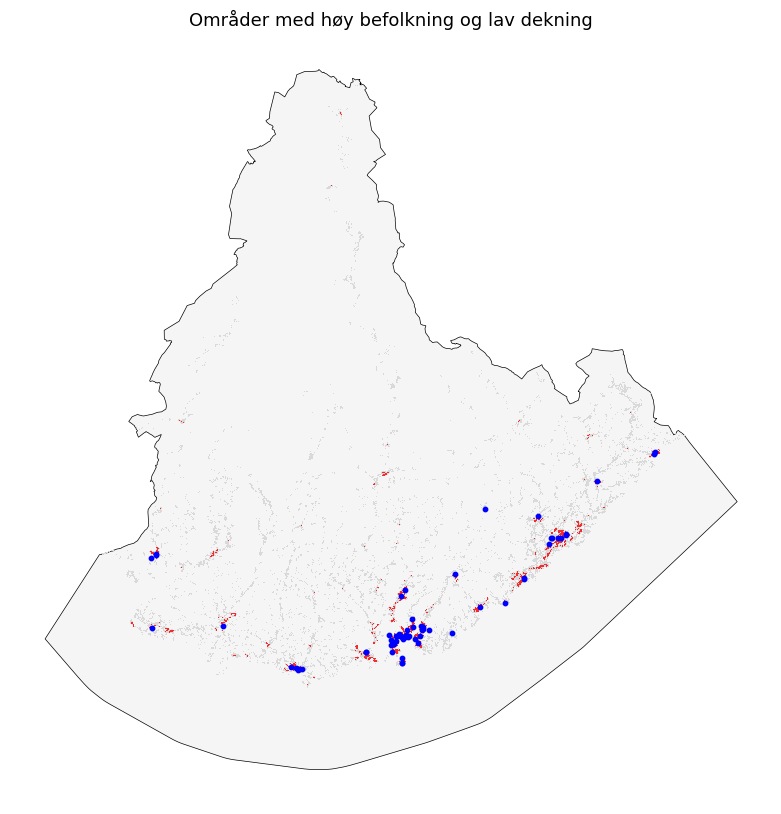

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")

# bakgrunn
gdf_agder.plot(ax=ax, color="#f5f5f5", edgecolor="black", linewidth=0.5)

# alle ruter
gdf_population_agder.plot(ax=ax, color="#d9d9d9", linewidth=0)

# svake områder (rød)
gdf_low_coverage.plot(ax=ax, color="red", alpha=0.8)

# shelters
gdf_shelters.plot(ax=ax, color="blue", markersize=10)

ax.set_title("Områder med høy befolkning og lav dekning", fontsize=13)
ax.set_axis_off()

plt.show()

Valg av terskelverdier (minimum befolkning og maksimum dekning) påvirker hvilke områder som identifiseres som problematiske. Tersklene i denne analysen er valgt for å fremheve områder med både høy befolkning og lav tilgjengelighet.

## 4.7 Forbedret visualisering av resultater

For å gjøre resultatene lettere å tolke, presenteres en forenklet visualisering av analysen.

Kartet viser:

- **Røde områder**: befolkningsruter med høy befolkning og lav dekning av tilfluktsrom
- **Blå punkter**: lokasjonene til eksisterende tilfluktsrom
- **linje**: avgrensning av Agder fylke

Ved å fjerne mindre viktige visuelle elementer og fremheve problemområdene tydelig, blir det enklere å identifisere hvor dekningen er mangelfull.

Kartet viser at mange av områdene med lav dekning ligger langs kysten og rundt tettsteder, noe som indikerer at tilgjengeligheten til tilfluktsrom ikke er jevnt fordelt.
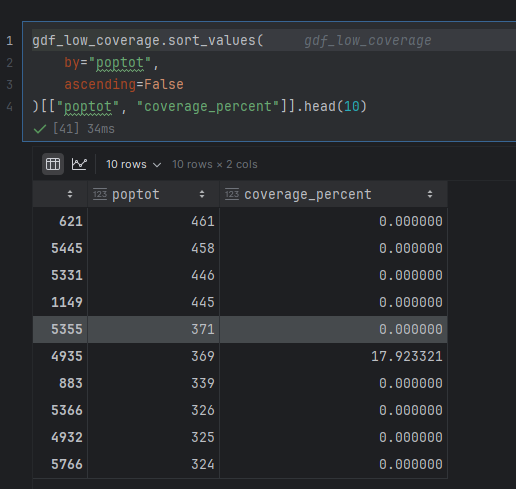

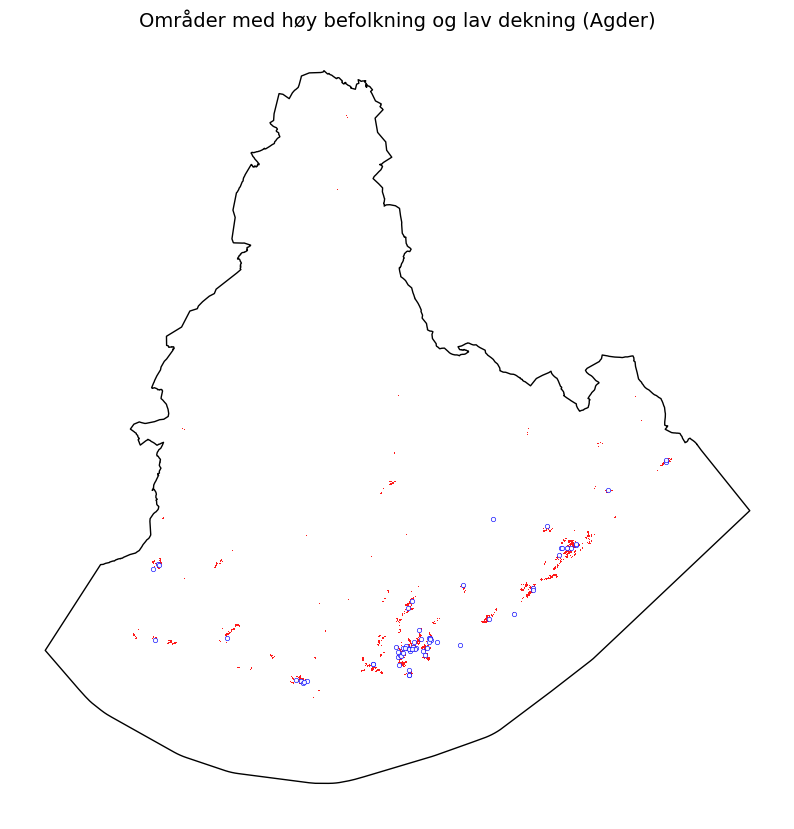

In [49]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.close("all")
mpl.rcdefaults()

fig, ax = plt.subplots(figsize=(10, 12), facecolor="white")
ax.set_facecolor("white")

# 1. Agder outline
gdf_agder.plot(
    ax=ax,
    color="none",
    edgecolor="black",
    linewidth=1
)

# 2. Problemområder
gdf_low_coverage.plot(
    ax=ax,
    color="red",
    alpha=0.9,
    markersize=5
)

# 3. Shelters
gdf_shelters.plot(
    ax=ax,
    color="white",
    edgecolor="blue",
    linewidth=0.5,
    markersize=10,
    alpha=0.9,
    zorder=5
)

ax.set_title(
    "Områder med høy befolkning og lav dekning (Agder)",
    fontsize=14
)

ax.set_axis_off()

plt.show()

## 4.8 Oppsummering av vektoranalyse

Den romlige analysen viser at tilfluktsrom i Agder i stor grad er lokalisert nær tettsteder og langs kysten. Samtidig viser resultatene at dekningen er begrenset, og at store deler av befolkningen ikke har et tilfluktsrom innenfor 500 meters avstand.

Beregningene viste at omtrent 20,6 % av befolkningen i Agder er dekket av buffersonene. Dette indikerer at majoriteten av befolkningen befinner seg utenfor den definerte tilgjengelighetsradiusen.

Videre viser analysen at dekningen er ujevnt fordelt geografisk. Flere områder med høy befolkning har lav eller ingen dekning, noe som ble identifisert gjennom filtrering av ruter med høy befolkning og lav dekning.

Kartvisualiseringene bekrefter dette mønsteret, og viser at mange av disse områdene ligger langs kysten og rundt urbane områder. Dette tyder på at selv om tilfluktsrom finnes i nærheten av tettsteder, er kapasiteten eller plasseringen ikke tilstrekkelig til å dekke hele befolkningen.

Analysen demonstrerer hvordan GIS-metoder som buffer, overlay og romlig aggregering kan brukes til å avdekke geografiske forskjeller i tilgjengelighet og identifisere potensielle svakheter i beredskapen.
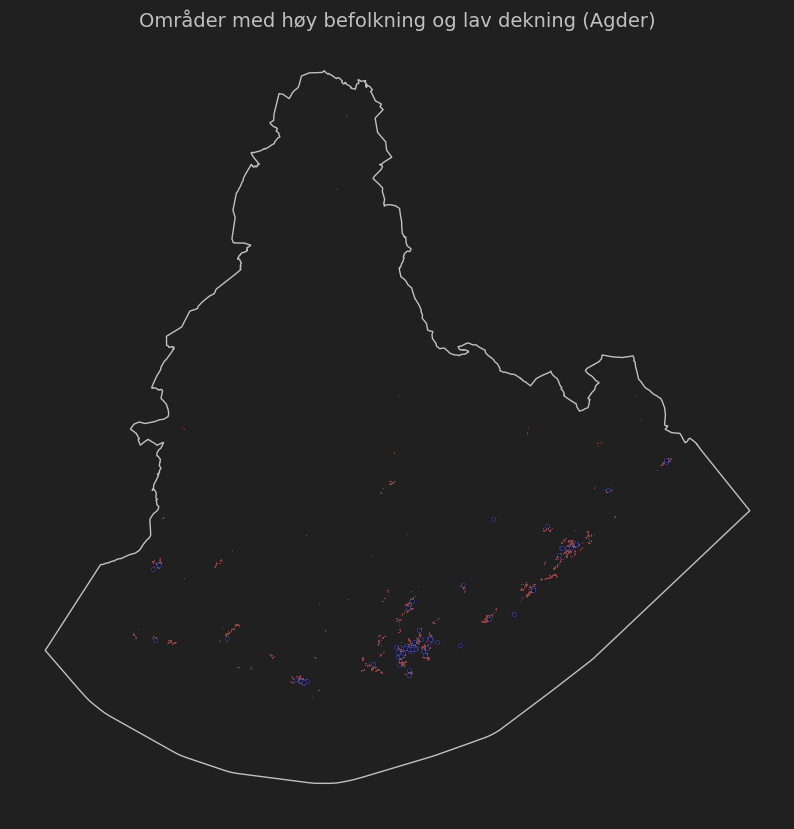
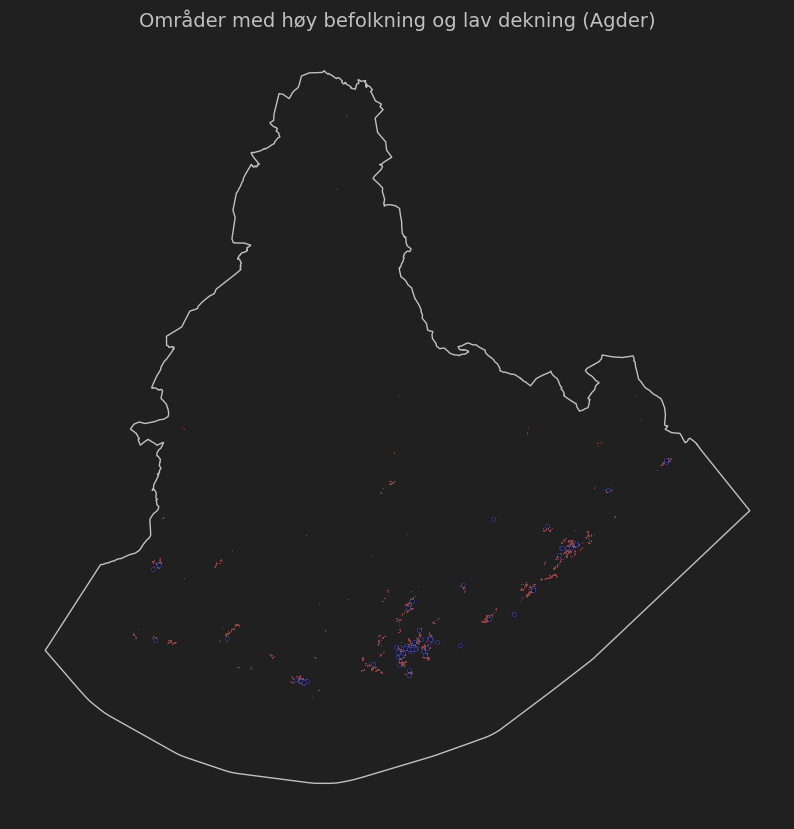

## Del 5: Rasteranalyse

I denne delen av analysen benyttes rasterdata for å undersøke terrengforhold i Agder. Mens vektordata representerer objekter som punkter og polygoner, består rasterdata av et rutenett der hver celle har en verdi.

Rasteranalyse gir mulighet til å analysere kontinuerlige fenomener, som høyde og terrengform, og kan brukes til å supplere den romlige analysen av tilfluktsrom og befolkning.

I denne delen gjennomføres følgende steg:

- Innlasting av høydedata (DEM)
- Beregning av helning (slope)
- Visualisering av terreng (hillshade)
- Konvertering av raster til polygoner (polygonize)

Formålet er å utforske hvordan terreng kan påvirke tilgjengelighet og gi en mer helhetlig forståelse av analyseområdet.